# Wstęp
Zadanie 6 stanowi wprowadzenie w tematykę *data augmentation*. Ze względu na złożonośc modeli głębokich, zwykle wymagają one bardzo dużych zbiorów danych do dobrego wyuczenia. Jednym ze sposobów na skalowanie ilości dostępnych danych są metody tzw. augmentacji - przekształcenia na danych które mamy, aby utworzyć nowe przykłady o znanych etykietach. Pod koniec zadania wprowadzona jest również koncepcja *skip connections*, będących istotnym elementem współczesnych architektur konwolucyjnych i nie tylko.

# Cel ćwiczenia

Celem ćwiczenia jest zapoznanie się z

*    koncepcją augmentacji danych
*    implementacją metod augmentacji danych obrazowych w torch.transforms
*    koncepcją augmentacji niezależnej od dziedziny
*    modelami sieci głębokich ze skip connections

# Augmentacja danych obrazowych

W pierwszej kolejności zapoznajmy się z funkcjonalnością augmentacji danych obrazowych. W pytorch funkcjonalność ta realizowana jest przez transformacje wykonywane na obrazach przez `torchvision.transforms`.

Transformacje które typowo wykorzystuje się w augmentacji to standardowe przekształcenia afiniczne obrazu - rotacje, dobicia, skalowanie. Oczywiście, pownniśmy dobierać transformacje z takich, po których rzeczywiście oczekujemy inwariancji - przekształcony obraz będziemy podawać do sieci z tą samą etykietą. Przykładowo, na zbiorze odręcznie pisanych cyfr MNIST ograniczymy zakres obrotów czy wykorzystanie odbicia w osi poziomej, jako że niechcemy pomylić 5 z 2 czy 6 z 9.

Zapoznaj się z dokumentacją transforms tutaj:

https://pytorch.org/vision/stable/transforms.html

Kod poniżej wczytuje CIFAR 10 i pokazuje wyniki przykładowej augmentacji - losowej rotacji o kąt -30 do 30 stopni.

/usr/local/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


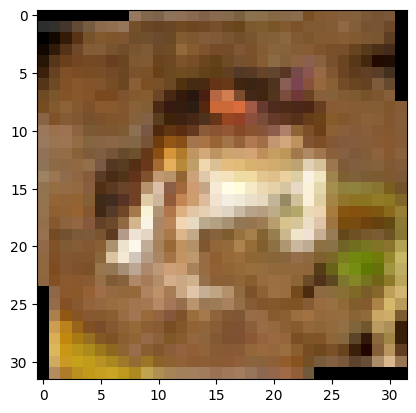

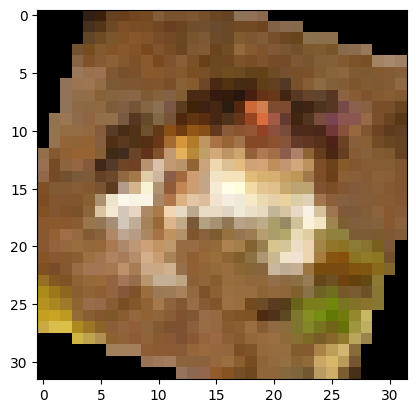

In [29]:
import torch
import torchvision
import torchvision.transforms as transforms
from matplotlib import pyplot as plt

RANDOM_SEED = 42

transform = transforms.Compose([
    transforms.RandomRotation(30),
    transforms.ToTensor()
])

train_ds = torchvision.datasets.CIFAR10("cifar_root", transform=transform, download=True)
img, label = train_ds[0]

plt.imshow(img.permute(1,2,0))
plt.show()

img, label = train_ds[0]

plt.imshow(img.permute(1,2,0))
plt.show()

Widzimy tutaj kolejny potencjalny problem z augmentacjami: ze względu na konieczność utrzymania stałego kształtu wejścia, augmentacje mogą wprowadzać artefakty takie jak czarne fragmenty na krawędziach obrazu czy aliasing wynikający z niskiej rozdzielczości.

Poniżej kod pomocniczy z laboratorium 3, można zastąpić go własną implementacją pętli uczącej uwzględniającej ulepszenia wykonane na laboratoriach 4 i 5. W zadaniach poniżej wystarczy porównać końcowy wynik uczenia, nie jest wymagane wyrysowywanie pełnych krzywych w tensorboard niemniej mogą one pomóc w analizie otrzymanych wyników.

In [30]:
import torchvision
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from typing import Tuple, Dict, List
from tqdm import tqdm
import copy
import numpy as np
from sklearn.metrics import f1_score

def count_correct(
    y_pred: torch.Tensor, y_true: torch.Tensor
) -> torch.Tensor:
    preds = torch.argmax(y_pred, dim=1)
    return (preds == y_true).float().sum()

def validate(
    model: nn.Module,
    loss_fn: torch.nn.CrossEntropyLoss,
    dataloader: DataLoader
) -> Tuple[float, float, float]:
    model.eval()
    total_loss = 0
    correct = 0
    all_preds = []
    all_labels = []
    device = next(model.parameters()).device
    
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            
            # CrossEntropyLoss returns mean by default, so we multiply by batch size to get sum
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item() * len(y_batch)
            
            preds = torch.argmax(y_pred, dim=1)
            correct += (preds == y_batch).float().sum().item()
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
            
    total_samples = len(dataloader.dataset)
    avg_loss = total_loss / total_samples
    acc = correct / total_samples
    f1 = f1_score(all_labels, all_preds, average='macro')

    return avg_loss, acc, f1

def fit(
    model: nn.Module, optimiser: optim.Optimizer,
    loss_fn: torch.nn.CrossEntropyLoss, train_dl: DataLoader,
    val_dl: DataLoader, epochs: int,
    patience: int = 5,
    print_metrics: bool = False
) -> Dict[str, List[float]]:
    history = {
        'train_loss': [], 'train_acc': [], 'train_f1': [],
        'val_loss': [], 'val_acc': [], 'val_f1': []
    }
    
    best_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    
    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in tqdm(train_dl, desc=f"Epoch {epoch}"):
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)

            loss.backward()
            optimiser.step()
            optimiser.zero_grad()

        # Evaluation
        train_loss, train_acc, train_f1 = validate(model, loss_fn, train_dl)
        val_loss, val_acc, val_f1 = validate(model, loss_fn, val_dl)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['train_f1'].append(train_f1)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        
        if print_metrics:
            print(f"Epoch {epoch}: train loss = {train_loss:.3f} (acc: {train_acc:.3f}, f1: {train_f1:.3f}), "
                  f"val loss = {val_loss:.3f} (acc: {val_acc:.3f}, f1: {val_f1:.3f})")
        
        if val_loss < best_loss:
            best_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch}")
                break
                
    model.load_state_dict(best_model_wts)
    return history


# Zadanie 1

Wykorzystując klasę ThreeLayerCNN z `channels=32`, spróbuj dobrać augmentacje danych tak aby poprawić wyniki względem jej braku na zbiorze CIFAR10.

In [31]:
class ThreeLayerCNN(torch.nn.Module):
  def __init__(self, channels: int, labels: int):
    super().__init__()
    self.model = torch.nn.Sequential()
    self.model.add_module("in_conv",
                          torch.nn.Conv2d(3, channels, 1))
    self.model.add_module("relu_1", torch.nn.ReLU())
    self.model.add_module("conv_1",
                          torch.nn.Conv2d(channels, channels, 3, padding=1))
    self.model.add_module("relu_2", torch.nn.ReLU())
    self.model.add_module("max_pool_1", torch.nn.MaxPool2d(2))
    self.model.add_module("conv_2",
                          torch.nn.Conv2d(channels, channels, 3, padding=1))
    self.model.add_module("relu_3", torch.nn.ReLU())
    self.model.add_module("max_pool_2", torch.nn.MaxPool2d(2))
    self.model.add_module("flatten", torch.nn.Flatten())
    self.model.add_module("linear", torch.nn.Linear( channels * 64 , 10)) #uzupełnij

  def forward(self, x):
    return self.model(x)

Zaprogramuj eksperyment tak, aby w pętli sprawdzać kolejne potencjalne wersje potoku przetwarzania (różniące się tutaj tylko augmentacją), a na końcu wybrać najlepszą - tak aby możliwe było powtórzenie całego eksperymentu uzasadniającego wybór! Transformacja z augmentacją ma być wywoływana tylko na danych treningowych.

Spróbuj znaleźć również przykład augmentacji pogarszającej wynik w stosunku do bazowego otrzymanego bez augmentacji. Wykorzystaj uczenie na 50 epok i optymalizator Adam z domyślnymi parametrami, bez regularyzacji.

In [32]:
import torchvision.transforms as T
from torch.utils.data import Subset

experiments = {
    "baseline":               T.Compose([T.ToTensor()]),
    "horizontal_flip":        T.Compose([T.RandomHorizontalFlip(), T.ToTensor()]),
    "crop_and_flip":          T.Compose([T.RandomCrop(32, padding=4), T.RandomHorizontalFlip(), T.ToTensor()]),
    "color_jitter":           T.Compose([T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), T.ToTensor()]),
    "worse_aug (strong_blur)": T.Compose([T.GaussianBlur(kernel_size=9), T.ToTensor()])
}

def run_exp(name, loss_fn, fit_fn, model, optimiser, transform=None):
    torch.manual_seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)
    if transform is None:
        transform = T.ToTensor()
    print(f"Running experiment: {name}")

    train_ds_aug   = torchvision.datasets.CIFAR10("cifar_root", transform=transform,    train=True,  download=True)
    train_ds_plain = torchvision.datasets.CIFAR10("cifar_root", transform=T.ToTensor(), train=True,  download=False)
    test_ds        = torchvision.datasets.CIFAR10("cifar_root", transform=T.ToTensor(), train=False, download=False)

    n         = len(train_ds_aug)
    indices   = torch.randperm(n).tolist()
    train_idx = indices[:int(0.9 * n)]
    val_idx   = indices[int(0.9 * n):]

    train_dl = DataLoader(Subset(train_ds_aug,   train_idx), batch_size=64, shuffle=True)
    val_dl   = DataLoader(Subset(train_ds_plain, val_idx),   batch_size=64)
    test_dl  = DataLoader(test_ds, batch_size=64)

    metrics = fit_fn(model=model, optimiser=optimiser, loss_fn=loss_fn,
                     train_dl=train_dl, val_dl=val_dl, epochs=50, patience=5)

    _, final_acc, final_f1 = validate(model, loss_fn, test_dl)
    metrics["test_acc"] = final_acc
    metrics["test_f1"]  = final_f1
    print(f"Final TEST metrics for {name}: Acc:{final_acc:.3f}; F1:{final_f1:.3f}")

    return metrics


In [33]:
loss_fn = nn.CrossEntropyLoss()
results = {}

for name, transform in experiments.items():
    model = ThreeLayerCNN(channels=32, labels=10)
    optimiser = optim.Adam(model.parameters())
    results[name] = run_exp(name, loss_fn, fit, model, optimiser, transform)

print("Summary of results (Zadanie 1):")
for name, metrics in results.items():
    print(f"{name}: Acc: {metrics['test_acc']:.3f} F1: {metrics['test_f1']:.3f}")


Running experiment: baseline


Epoch 15: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 704/704 [00:06<00:00, 105.18it/s]


Early stopping at epoch 15
Final TEST metrics for baseline: Acc:0.676; F1:0.678
Running experiment: horizontal_flip


/usr/local/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")
Epoch 24: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 704/704 [00:08<00:00, 87.53it/s]


Early stopping at epoch 24
Final TEST metrics for horizontal_flip: Acc:0.710; F1:0.711
Running experiment: crop_and_flip


...

Early stopping at epoch 33
Final TEST metrics for crop_and_flip: Acc:0.717; F1:0.717
Running experiment: color_jitter


/usr/local/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")
Epoch 18: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 704/704 [00:15<00:00, 44.78it/s]


Early stopping at epoch 18
Final TEST metrics for color_jitter: Acc:0.675; F1:0.674
Running experiment: worse_aug (strong_blur)


/usr/local/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")
Epoch 18: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 704/704 [00:27<00:00, 25.51it/s]


Early stopping at epoch 18
Final TEST metrics for worse_aug (strong_blur): Acc:0.634; F1:0.630
Summary of results (Zadanie 1):
baseline: Acc: 0.676 F1: 0.678
horizontal_flip: Acc: 0.710 F1: 0.711
crop_and_flip: Acc: 0.717 F1: 0.717
color_jitter: Acc: 0.675 F1: 0.674
worse_aug (strong_blur): Acc: 0.634 F1: 0.630


# Mixup - augmentacja ogólna

Augmentacja daje nam spore możliwości w sytuacji, gdy w dziedzinie danych jesteśmy w stanie wskazać przekształcenia na kóre nasz model powinien być **inwariantny** - dla obrazków niewielkie skalowanie czy przesunięcie nie powinno zmieniać wyniku, zaś dla tekstu, podstawianie synonimów może spełniać podobną rolę. Ale w augmentacji danych możliwe jest też podejście niezależne od typu danych, wynikające z obserwacji dotyczących dynamiki uczenia sieci głębokich w ogóle. Ciekawym przykładem jest tu augmentacja Mixup:

https://arxiv.org/abs/1710.09412

Zasada działania mixup jest niezwykle prosta - generujemy nowe przykłady jako **kombinacje liniowe** tych istniejących w zbiorze danych i oczekujemy, że ich etykiety również będą kombinacjami liniowymi etykiet. Innymi słowy, dla pary przykładów z etykietami: $(x_1, y_1)$, $(x_2, y_2)$, możemy wygenerować przykład $(x', y')$:

$x' = \lambda x_1 + (1-\lambda) x_2$

$y' = \lambda y_1 + (1-\lambda) y_2$

Wartość $\lambda$ jest tutaj losowana z rozkładu Beta - animacja podana na https://en.wikipedia.org/wiki/Beta_distribution#Definitions dobrze obrazuje, jak wygląda ten rozkład dla różnych parametryzacji.

# Zadanie 2

Zmodyfikuj funkcję fit tak, aby uczyć zgodnie z podanym wyżej sformułowaniem augmentacji Mixup. (Pamiętaj, że model musi przyjmować etykiety w postaci kombinacji dwóch klas. Będzie to wymagało modyfikacji funkcji kosztu! )

In [34]:
import torch
import numpy as np

def mixup_data(x, y, alpha=1.0):
    '''Zwraca wymieszane wejścia, pary etykiet oraz wagę lambda.'''
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(x.device)

    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    '''Oblicza ważoną funkcję kosztu dla dwóch etykiet.'''
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

def fit_mixup(
    model: nn.Module, optimiser: optim.Optimizer,
    loss_fn: torch.nn.CrossEntropyLoss, train_dl: DataLoader,
    val_dl: DataLoader, epochs: int,
    alpha: float = 1.0, # Parametr rozkładu Beta (zazwyczaj 1.0)
    patience: int = 5,
    print_metrics: bool = False
) -> Dict[str, List[float]]:
    history = {
        'train_loss': [], 'train_acc': [], 'train_f1': [],
        'val_loss': [], 'val_acc': [], 'val_f1': []
    }
    
    best_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    
    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in tqdm(train_dl, desc=f"Epoch {epoch} (Mixup)"):
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            # --- SEKCJA MIXUP ---
            # 1. Generujemy wymieszane dane
            mixed_x, y_a, y_b, lam = mixup_data(X_batch, y_batch, alpha)
            
            # 2. Forward pass na wymieszanych danych
            y_pred = model(mixed_x)
            
            # 3. Obliczamy zmodyfikowany koszt (liniowa kombinacja kosztów dla obu klas)
            loss = mixup_criterion(loss_fn, y_pred, y_a, y_b, lam)
            # --------------------

            loss.backward()
            optimiser.step()
            optimiser.zero_grad()

        # Ewaluacja (zawsze na czystych danych bez Mixup!)
        train_loss, train_acc, train_f1 = validate(model, loss_fn, train_dl)
        val_loss, val_acc, val_f1 = validate(model, loss_fn, val_dl)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['train_f1'].append(train_f1)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        
        if print_metrics:
            print(f"Epoch {epoch}: train loss = {train_loss:.3f} (acc: {train_acc:.3f}, f1: {train_f1:.3f}), "
                  f"val loss = {val_loss:.3f} (acc: {val_acc:.3f}, f1: {val_f1:.3f})")
        
        if val_loss < best_loss:
            best_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch}")
                break
                
    model.load_state_dict(best_model_wts)
    return history


Sprawdź, czy uzyskuje ona przewagę nad modelem trenowanym bez augmentacji.



In [35]:
loss_fn   = nn.CrossEntropyLoss()
model     = ThreeLayerCNN(channels=32, labels=10)
optimiser = optim.Adam(model.parameters())
results["mixup"] = run_exp("mixup", loss_fn, fit_mixup, model, optimiser)

print("Porownanie baseline - bez Mixup vs z Mixup:")
print(f"  baseline (fit):       Acc={results['baseline']['test_acc']:.3f}  F1={results['baseline']['test_f1']:.3f}")
print(f"  baseline (fit_mixup): Acc={results['mixup']['test_acc']:.3f}  F1={results['mixup']['test_f1']:.3f}")


Running experiment: mixup


/usr/local/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")
Epoch 45 (Mixup): 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 704/704 [00:05<00:00, 117.97it/s]


Early stopping at epoch 45
Final TEST metrics for mixup: Acc:0.706; F1:0.703
Porownanie baseline - bez Mixup vs z Mixup:
  baseline (fit):       Acc=0.676  F1=0.678
  baseline (fit_mixup): Acc=0.706  F1=0.703


# Skrótowe połączenia

W kontekście sieci konwolucyjnych warto zpoznać się jeszcze z jedną istotną koncepcją: połączenia omijające warstwy, poprzez konkatenacje ich wyniku z wynikami dalszych warstw lub dodawanie ich wyniku do wyjścia dalszej warstwy (w drugim przypadku mówimy też o połączeniach *rezydualnych*). Połączenia takie są potrzebne szczególnie przy trenowaniu sieci bardzo głębokich, zawierających dziesiątki czy nawet ponad 100 warstw, czego nie będziemy w stanie realistycznie zrealizować w czasie naszych laboratoriów. Niemniej warto zapoznać się zarówno z samą ideą, jak i ich implementacją, jako że przy pracy z architekturami *state of the art* będziemy często natykać się na takie konstrukcje.

W konstrukcji sieci z połączeniamy pomijającymi warstwy i połączeniami rezydualnymi często będziemy spotykać się z powtarzalnymi *blokami* obejmującymi kilka warstw - dobrą praktyką implementacyjną jest wydzielanie takich bloków jako osobnych podklas `torch.nn.Module`. Warto też z góry zwrócić uwagę, że znane nam już `torch.nn.Sequential` nie uwzględnia połączeń innych niż sekwencyjne - czyli połączenia rezydualne i omijanie warstw nie wchodzi w grę, chyba że w obrębie wydzielonego bloku.

# Zadanie 3

Uzupełnij kod klasy SkipBlock tak, aby implementowała blok o zadanej strukturze.

Struktura SkipBlock:


*  zadana liczba `n` warstw konwolucyjnch, `channels x channels` kanałów, filtr 3x3, padding 1
*  aktywacja ReLU po każdej warstwie
*  pooling 2x pod koniec całego bloku
*  parametr `skip`: jeśli jest ustawiony na `true`, do wyjścia po ReLU należy **dodać** pierwotne wejście do warstwy konwolucyjnej, jeśli `false` mamy zwyczajną sekwencję warstw konwolucyjnych z aktywacjami

(Dla `skip=false` i `n=1` struktura sieci powinna odpowiadać ThreeLayerCNN powyżej.)

In [36]:
class SkipBlock(torch.nn.Module):
    def __init__(self, channels: int, n: int, skip: bool):
        super().__init__()
        self.skip = skip
        self.convs = torch.nn.ModuleList([
            torch.nn.Conv2d(channels, channels, 3, padding=1) for _ in range(n)
        ])
        self.relu = torch.nn.ReLU()
        self.pool = torch.nn.MaxPool2d(2)

    def forward(self, x):
        for conv in self.convs:
            residual = x
            x = self.relu(conv(x))
            if self.skip:
                x = x + residual
        return self.pool(x)


class SkipBlockCNN(torch.nn.Module):
    def __init__(self, channels: int, labels: int, n: int, skip: bool):
        super().__init__()
        self.model = torch.nn.Sequential()
        self.model.add_module("in_conv", torch.nn.Sequential(
            torch.nn.Conv2d(3, channels, 1),
            torch.nn.ReLU()
        ))
        self.model.add_module("skip_1", SkipBlock(channels, n, skip))
        self.model.add_module("skip_2", SkipBlock(channels, n, skip))
        self.model.add_module("flatten", torch.nn.Flatten())
        self.model.add_module("linear", torch.nn.Linear(channels * 64, labels))

    def forward(self, x):
        return self.model(x)


 Wyucz sieć SkipBlockCNN i porównaj jej wyniki z wcześniej uzykanymi. Porównaj wyniki w zależności od tego, czy włączone są skip connections.

In [37]:
loss_fn      = nn.CrossEntropyLoss()
results_skip = {}

# Wszystkie augmentacje z experiments dla skip=False i skip=True
for exp_name, transform in experiments.items():
    for skip in [False, True]:
        name = f"{exp_name}_skip={skip}"
        model = SkipBlockCNN(channels=32, labels=10, n=1, skip=skip)
        optimiser = optim.Adam(model.parameters())
        results_skip[name] = run_exp(name, loss_fn, fit, model, optimiser, transform)

# 1x Mixup dla skip=False i skip=True (domyslny transform=ToTensor)
for skip in [False, True]:
    name      = f"mixup_skip={skip}"
    model     = SkipBlockCNN(channels=32, labels=10, n=1, skip=skip)
    optimiser = optim.Adam(model.parameters())
    results_skip[name] = run_exp(name, loss_fn, fit_mixup, model, optimiser)

print("Podsumowanie wynikow SkipBlockCNN:")
for name, metrics in results_skip.items():
    print(f"  {name}: Acc={metrics['test_acc']:.3f}  F1={metrics['test_f1']:.3f}")


Running experiment: baseline_skip=False


/usr/local/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")
Epoch 14: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 704/704 [00:05<00:00, 118.77it/s]


Early stopping at epoch 14
Final TEST metrics for baseline_skip=False: Acc:0.685; F1:0.684
Running experiment: baseline_skip=True


/usr/local/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")
Epoch 30: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 704/704 [00:05<00:00, 121.22it/s]


Early stopping at epoch 30
Final TEST metrics for baseline_skip=True: Acc:0.680; F1:0.678
Running experiment: horizontal_flip_skip=False


...

Early stopping at epoch 12
Final TEST metrics for worse_aug (strong_blur)_skip=True: Acc:0.592; F1:0.589
Running experiment: mixup_skip=False


/usr/local/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")
Epoch 45 (Mixup): 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 704/704 [00:06<00:00, 114.49it/s]


Early stopping at epoch 45
Final TEST metrics for mixup_skip=False: Acc:0.704; F1:0.702
Running experiment: mixup_skip=True


/usr/local/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")
Epoch 49 (Mixup): 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 704/704 [00:06<00:00, 115.88it/s]


Final TEST metrics for mixup_skip=True: Acc:0.666; F1:0.659
Podsumowanie wynikow SkipBlockCNN:
  baseline_skip=False: Acc=0.685  F1=0.684
  baseline_skip=True: Acc=0.680  F1=0.678
  horizontal_flip_skip=False: Acc=0.722  F1=0.722
  horizontal_flip_skip=True: Acc=0.685  F1=0.687
  crop_and_flip_skip=False: Acc=0.739  F1=0.736
  crop_and_flip_skip=True: Acc=0.643  F1=0.640
  color_jitter_skip=False: Acc=0.656  F1=0.654
  color_jitter_skip=True: Acc=0.684  F1=0.680
  worse_aug (strong_blur)_skip=False: Acc=0.631  F1=0.629
  worse_aug (strong_blur)_skip=True: Acc=0.592  F1=0.589
  mixup_skip=False: Acc=0.704  F1=0.702
  mixup_skip=True: Acc=0.666  F1=0.659


# Wykresy

,test_acc,test_f1,train_f1,train_acc
experiment,,,,
crop_and_flip_skip=False,0.739,0.736,0.720,0.721
horizontal_flip_skip=False,0.722,0.722,0.781,0.783
crop_and_flip,0.717,0.717,0.693,0.693
horizontal_flip,0.710,0.711,0.780,0.780
mixup,0.706,0.703,0.793,0.796
mixup_skip=False,0.704,0.702,0.766,0.770
horizontal_flip_skip=True,0.685,0.687,0.726,0.723
baseline_skip=False,0.685,0.684,0.769,0.770
color_jitter_skip=True,0.684,0.680,0.735,0.741


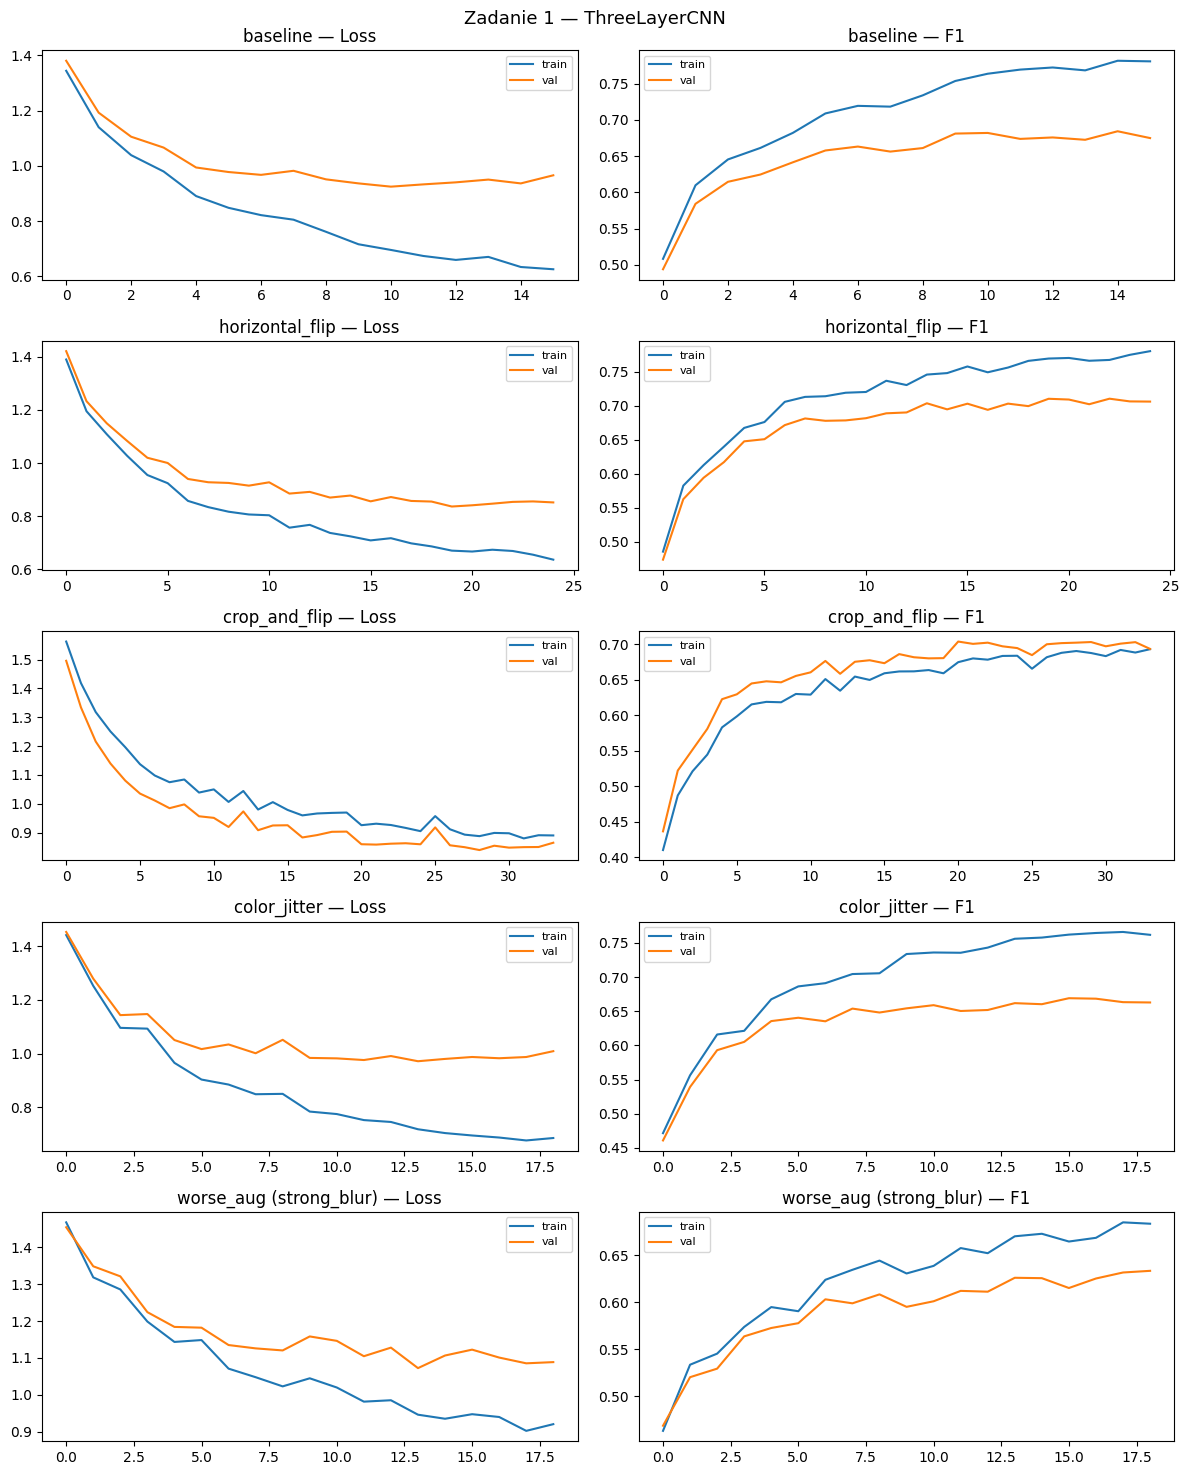

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────────
# Tabela wyników wszystkich eksperymentów
# ─────────────────────────────────────────────────────────────────
rows = []
for name, m in results.items():
    rows.append({"experiment": name,
                 "test_acc": m["test_acc"], "test_f1": m["test_f1"], "train_f1": m["train_f1"][-1], "train_acc": m["train_acc"][-1]})
for name, m in results_skip.items():
    rows.append({"experiment": name,
                 "test_acc": m["test_acc"], "test_f1": m["test_f1"], "train_f1": m["train_f1"][-1], "train_acc": m["train_acc"][-1]})

rows = sorted(rows, key=lambda r: (r["experiment"]))
df = pd.DataFrame(rows).set_index(["experiment"]).sort_values(by=["test_f1"], ascending=False)
display(df.style.format({"test_acc": "{:.3f}", "test_f1": "{:.3f}", "train_f1": "{:.3f}", "train_acc": "{:.3f}"}))


# ─────────────────────────────────────────────────────────────────
# Zadanie 1 — krzywe dla każdej augmentacji
# ─────────────────────────────────────────────────────────────────
task1_names = [k for k in results if k != "mixup"]
n = len(task1_names)
fig, axes = plt.subplots(n, 2, figsize=(12, 3 * n))
fig.suptitle("Zadanie 1 — ThreeLayerCNN", fontsize=13)
for i, name in enumerate(task1_names):
    m = results[name]
    ep = range(len(m['train_loss']))
    axes[i, 0].plot(ep, m['train_loss'], label='train')
    axes[i, 0].plot(ep, m['val_loss'],   label='val')
    axes[i, 0].set_title(f"{name} — Loss")
    axes[i, 0].legend(fontsize=8)
    axes[i, 1].plot(ep, m['train_f1'], label='train')
    axes[i, 1].plot(ep, m['val_f1'],   label='val')
    axes[i, 1].set_title(f"{name} — F1")
    axes[i, 1].legend(fontsize=8)
plt.tight_layout()
plt.show()








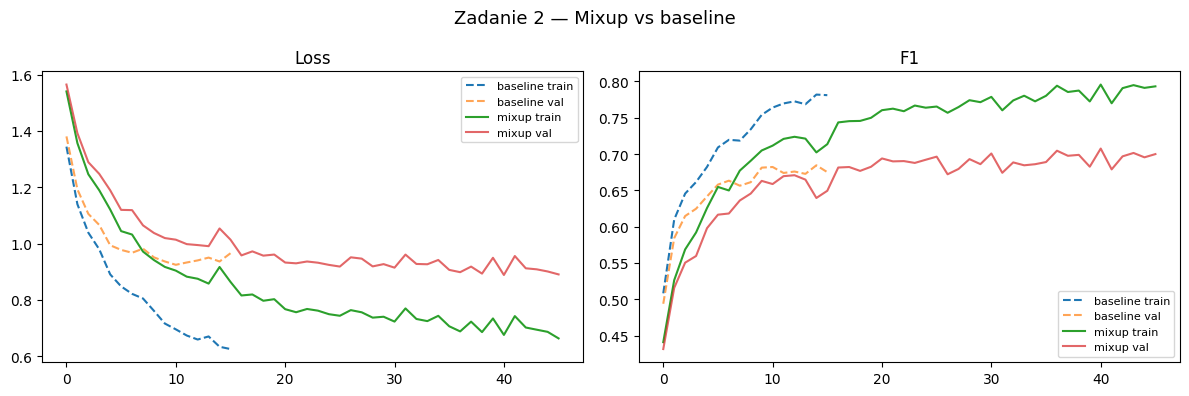

In [39]:
# ─────────────────────────────────────────────────────────────────
# Zadanie 2 — Mixup vs baseline
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Zadanie 2 — Mixup vs baseline", fontsize=13)
for name, ls in [("baseline", "--"), ("mixup", "-")]:
    m = results[name]
    ep = range(len(m['train_loss']))
    axes[0].plot(ep, m['train_loss'], linestyle=ls, label=f'{name} train')
    axes[0].plot(ep, m['val_loss'],   linestyle=ls, label=f'{name} val', alpha=0.7)
    axes[1].plot(ep, m['train_f1'],   linestyle=ls, label=f'{name} train')
    axes[1].plot(ep, m['val_f1'],     linestyle=ls, label=f'{name} val', alpha=0.7)
axes[0].set_title("Loss"); axes[0].legend(fontsize=8)
axes[1].set_title("F1");   axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

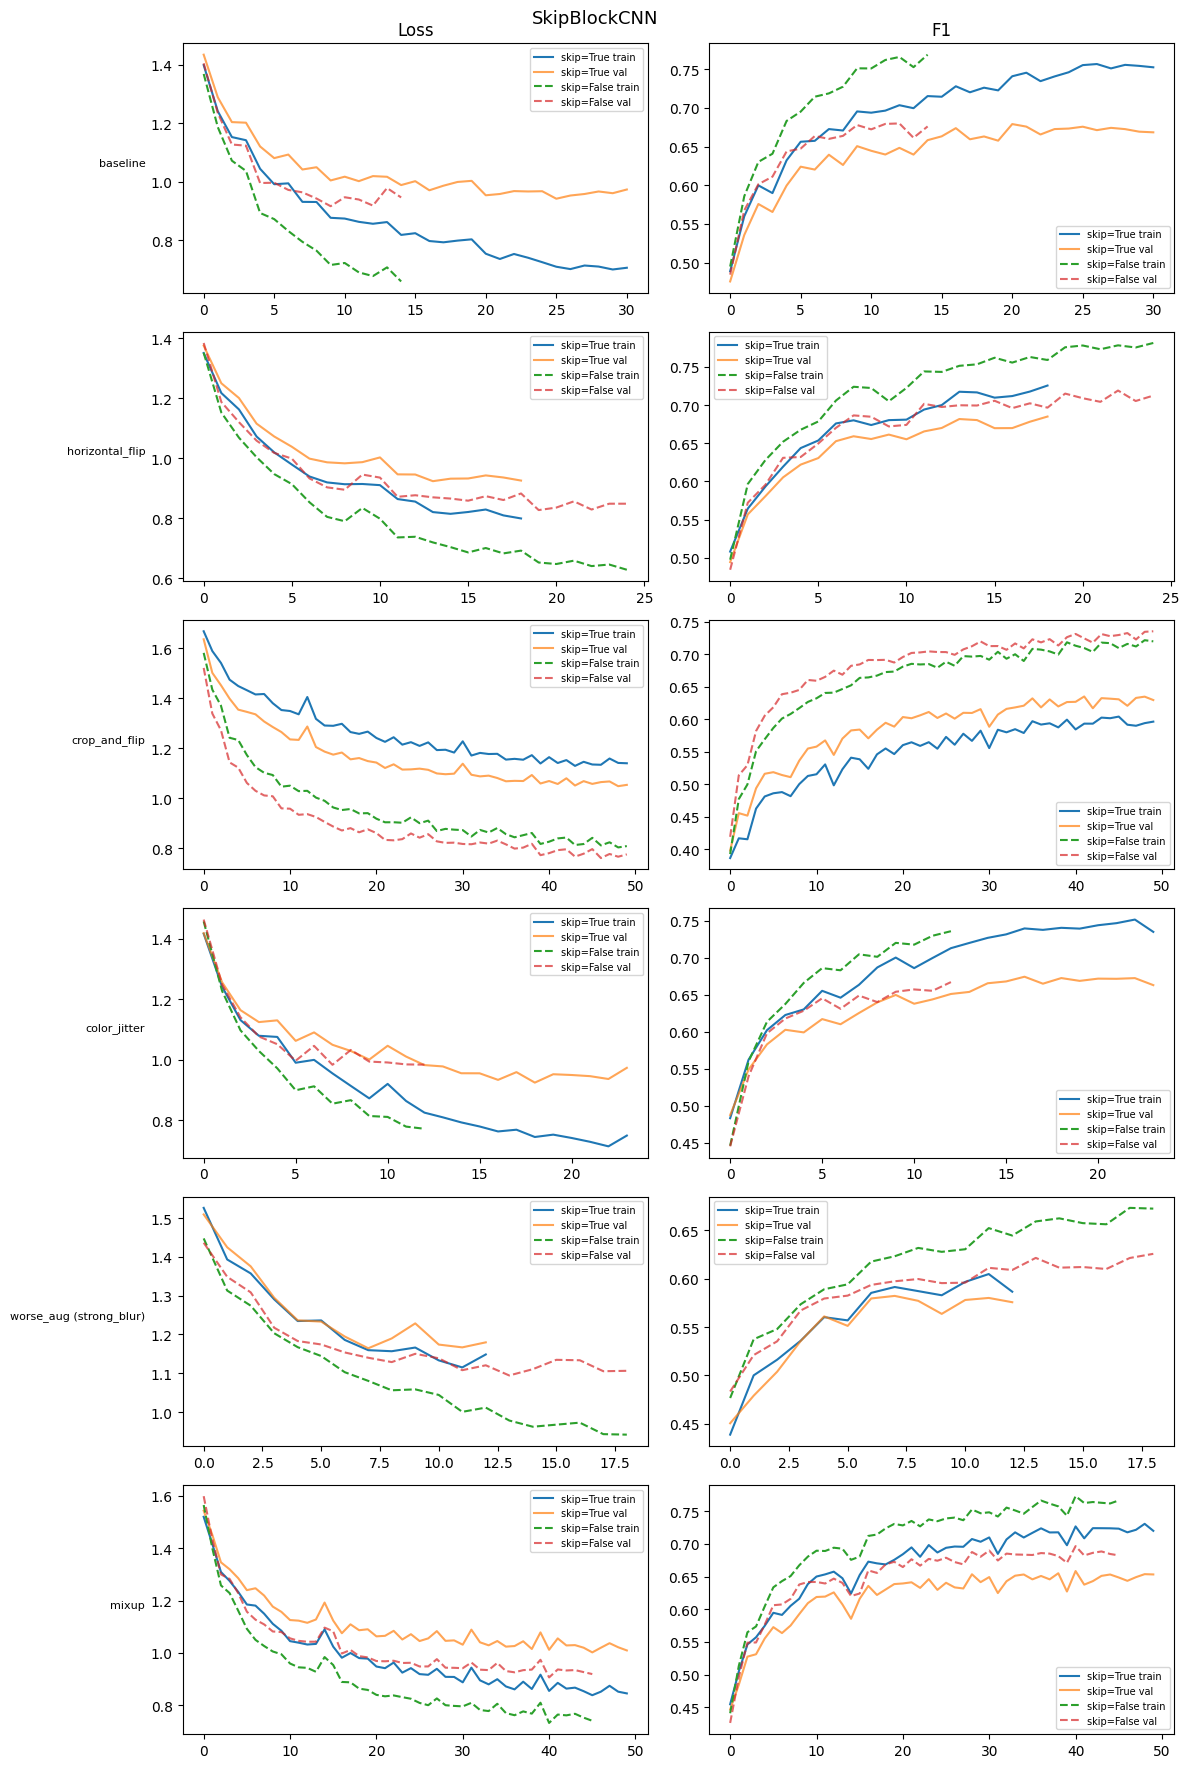

In [40]:
base_names = list(experiments.keys()) + ["mixup"]
n = len(base_names)
fig, axes = plt.subplots(n, 2, figsize=(12, 3 * n))
fig.suptitle("SkipBlockCNN", fontsize=13)

axes[0, 0].set_title("Loss")
axes[0, 1].set_title("F1")

for i, base in enumerate(base_names):
    axes[i, 0].set_ylabel(base, rotation=0, ha='right', fontsize=8)
    for skip, ls in [(True, '-'), (False, '--')]:
        key = f"{base}_skip={skip}"
        if key not in results_skip:
            continue
        m  = results_skip[key]
        ep = range(len(m['train_loss']))
        label = f"skip={skip}"
        axes[i, 0].plot(ep, m['train_loss'], linestyle=ls, label=f'{label} train')
        axes[i, 0].plot(ep, m['val_loss'],   linestyle=ls, label=f'{label} val', alpha=0.7)
        axes[i, 1].plot(ep, m['train_f1'],   linestyle=ls, label=f'{label} train')
        axes[i, 1].plot(ep, m['val_f1'],     linestyle=ls, label=f'{label} val', alpha=0.7)
    axes[i, 0].legend(fontsize=7)
    axes[i, 1].legend(fontsize=7)

plt.tight_layout()
plt.show()
